    The idea is to introduce the functions needed to construct the BdG Hamiltonian.
    
    1. Here we start with a dataframe which contains all the information about the square octagon lattice, namely (x, y) coordinates and neighbors.
    

In [1]:
using CSV
using DataFrames
using Plots
using DelimitedFiles

In [2]:
N = 2
nSites = 4*N^2
t2 = 1.0
tMatFileName = "data/N$(N)/ham_$(N)_t2_$(t2)"
twist = 0.0

0.0

In [3]:
## raw dataframe contains the unformatted dataframe where 4th column is NNN neighbor
df = CSV.read("data/N$(N)/raw_df_square-octagon$N.csv", DataFrame);

## this dataframe contains the formatted dataframe which structure [R, L, U, D], i.e., 
## For site i, first element is the site position to the right of i, second to the left and so on
## This is useful for when constructing the d-wave hamiltonian

# df = CSV.read("data/N$(N)/df_square-octagon$N.csv", DataFrame);

In [4]:
"""
    extract_geometry(df; formatted=false)

Arguments:
- `df`: dataframe containing square-octagon lattice data.
- `formatted`: if `true`, expects columns `n1:n4`; if `false`, expects `r1:r4`.

Returns:
- `x, y, neighbors`: x/y coordinates and a neighbor list per site.
"""
function extract_geometry(df; formatted::Bool=false)
    nSites = nrow(df)
    x = Vector{Float64}(df.x)
    y = Vector{Float64}(df.y)

    if formatted
        @assert all(name -> hasproperty(df, name), (:n1, :n2, :n3, :n4)) "formatted=true requires columns n1,n2,n3,n4"
        neighbors = [Int[df.n1[i], df.n2[i], df.n3[i], df.n4[i]] for i in 1:nSites]
    else
        @assert all(name -> hasproperty(df, name), (:r1, :r2, :r3, :r4)) "formatted=false requires columns r1,r2,r3,r4"
        neighbors = [Int[df.r1[i], df.r2[i], df.r3[i], df.r4[i]] for i in 1:nSites]
    end

    return x, y, neighbors
end


"""
    generate_t_map(neighbors; t1=1.0, t2=1.0)

Build a symmetric hopping map `tMap[(i,j)] = t` from a neighbor list.

Arguments:
- `neighbors`: vector where `neighbors[i] == [r1,r2,r3,r4]` with r1–r3 = NN and r4 = NNN
- `t1`: NN hopping (default `1.0`)
- `t2`: NNN hopping for r4 (default `1.0`)

Returns:
- `Dict{Tuple{Int,Int},Float64}` mapping site pairs `(i,j)` to hopping values.
"""
function generate_t_map(neighbors::Vector{Vector{Int}}; t1::Float64=1.0, t2::Float64=1.0)
    nSites = length(neighbors)
    tMap = Dict{Tuple{Int,Int}, Float64}()

    for i in 1:nSites
        @assert length(neighbors[i]) == 4 "neighbors[$i] must be [r1,r2,r3,r4] (r1–r3 NN, r4 NNN)."
        for (j_idx, j) in enumerate(neighbors[i])
            tVal = (j_idx == 4) ? t2 : t1
            tMap[(i, j)] = tVal
            tMap[(j, i)] = tVal
        end
    end

    return tMap
end

generate_t_map

In [5]:
"""
    build_t_matrix(neighbors, tMap; onsite=0.0, isComplex=false)

Construct the n×n tight-binding matrix tMat from a neighbor list and hopping map.
Assumes `neighbors[i]` lists the neighbors of site i (e.g. [r1,r2,r3,r4]).

Arguments:
- `neighbors`: Vector{Vector{Int}} neighbor list
- `tMap`: Dict{Tuple{Int,Int},Float64} with hopping amplitudes
- `onsite`: onsite energy added to the diagonal (default 0.0)
- `isComplex`: if true, returns ComplexF64 matrix

Returns:
- `tMat`: n×n hopping matrix
"""
function build_t_matrix(
    neighbors::Vector{Vector{Int}},
    tMap::Dict{Tuple{Int,Int},Float64};
    onsite::Float64=0.0,
    isComplex::Bool=false
)
    nSites = length(neighbors)
    T = isComplex ? ComplexF64 : Float64
    tMat = zeros(T, nSites, nSites)

    # onsite term (if any)
    if onsite != 0.0
        @inbounds for i in 1:nSites
            tMat[i,i] = onsite
        end
    end

    # fill hoppings
    @inbounds for i in 1:nSites
        for j in neighbors[i]
            tij = get(tMap, (i,j), 0.0)
            tij == 0.0 && continue
            tMat[i,j] += tij
        end
    end

    return tMat
end

build_t_matrix

In [6]:
x, y, neighbors = extract_geometry(df);

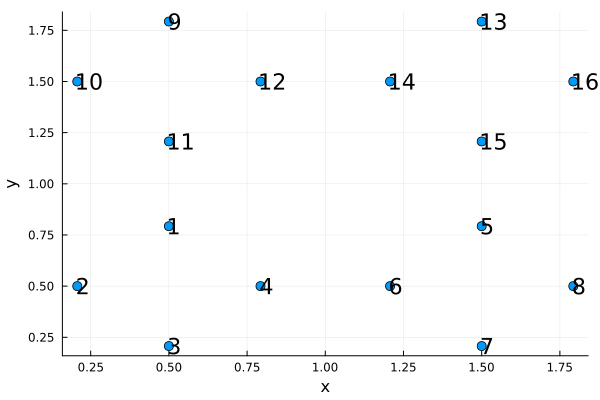

In [7]:
scatter(df.x, df.y, marker=:circle, ms=5, legend=false)

for i in 1:nrow(df)
    annotate!(df.x[i], df.y[i], text(string(df.siteIndex[i]), 15, :left))
end

xlabel!("x")
ylabel!("y")

In [8]:
tMap = generate_t_map(neighbors, t2=t2);

In [9]:
tMap

Dict{Tuple{Int64, Int64}, Float64} with 64 entries:
  (16, 13) => 1.0
  (16, 14) => 1.0
  (15, 5)  => 1.0
  (11, 10) => 1.0
  (4, 6)   => 1.0
  (9, 3)   => 1.0
  (7, 8)   => 1.0
  (14, 12) => 1.0
  (14, 15) => 1.0
  (13, 7)  => 1.0
  (2, 1)   => 1.0
  (6, 5)   => 1.0
  (2, 8)   => 1.0
  (3, 9)   => 1.0
  (16, 10) => 1.0
  (5, 15)  => 1.0
  (7, 6)   => 1.0
  (1, 3)   => 1.0
  (9, 10)  => 1.0
  (1, 4)   => 1.0
  (14, 13) => 1.0
  (3, 4)   => 1.0
  (12, 11) => 1.0
  (14, 16) => 1.0
  (13, 15) => 1.0
  ⋮        => ⋮

In [10]:
H0 = build_t_matrix(neighbors, tMap)
H0

16×16 Matrix{Float64}:
 0.0  1.0  1.0  1.0  0.0  0.0  0.0  0.0  …  0.0  1.0  0.0  0.0  0.0  0.0  0.0
 1.0  0.0  1.0  1.0  0.0  0.0  0.0  1.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.0  1.0  0.0  1.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 1.0  1.0  1.0  0.0  0.0  1.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  1.0  1.0  1.0     0.0  0.0  0.0  0.0  0.0  1.0  0.0
 0.0  0.0  0.0  1.0  1.0  0.0  1.0  1.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  1.0  1.0  0.0  1.0     0.0  0.0  0.0  1.0  0.0  0.0  0.0
 0.0  1.0  0.0  0.0  1.0  1.0  1.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0     1.0  1.0  1.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  1.0  1.0  0.0  0.0  0.0  1.0
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  1.0  0.0  1.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     1.0  1.0  0.0  0.0  1.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  

    Initially I used to generate the tight binding hamiltonian separately from an external FORTRAN program,
    but once we have our tMap generated we can easily construct the tight binding hamiltonian. The following program is just the way I did it initially.

In [11]:
"""
    generate_t_matrix(fileName::String; save::Bool=false, outFile::String="tMat.csv")::Matrix{ComplexF64}

Reads a real-valued text file with interleaved real and imaginary parts of a Hamiltonian,
reconstructs the complex matrix, and optionally saves it. This file is generated from an
external Fortran program.

Arguments
- `fileName::String`: Path to the input file with rows of [Re, Im, Re, Im, ...].
- `save::Bool`: Save the reconstructed matrix to `outFile` (default: `false`).
- `outFile::String`: Output file name for saving the matrix (default: `"tMat.csv"`).

Returns
- `H::Matrix{ComplexF64}`: The reconstructed complex Hamiltonian matrix.
"""
function generate_t_matrix(fileName::String; save::Bool=false, outFile::String="tMat.csv")::Matrix{ComplexF64}
    rawHam = Matrix{Float64}(readdlm(fileName))

    nrows = size(rawHam, 1)
    ncols = size(rawHam, 1)

    H = zeros(ComplexF64, nrows, ncols)

    for row in 1:nrows
        c = 1
        for col in 1:ncols
            H[row, col] = rawHam[row, c] + im * rawHam[row, c+1]
            c += 2
        end
    end

    if save
        # Check if all imaginary parts are zero (within tolerance)
        is_real_matrix = all(abs.(imag.(H)) .< 1e-12)

        if is_real_matrix
            writedlm(outFile, real(H), ',')
            println("Saved H to $outFile as real matrix (imag parts ~0).")
        else
            H_str = string.(H)
            writedlm(outFile, H_str, ',')
            println("Saved H to $outFile as complex matrix (human-readable).")
        end
    end

    return H
end

generate_t_matrix

In [12]:
tMatFort = generate_t_matrix(tMatFileName)

16×16 Matrix{ComplexF64}:
 0.0+0.0im  1.0+0.0im  1.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 1.0+0.0im  0.0+0.0im  1.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 1.0+0.0im  1.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 1.0+0.0im  1.0+0.0im  1.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  1.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  1.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  1.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  1.0+0.0im
 1.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     1.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     1.0+0.0im  1.0+0.0im  1.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  1.0+0.0im  1.0+0.0im
 0.0+0.0

In [13]:
function build_H_twisted(x::Vector{Float64},
                         neighbors::Vector{Vector{Int}},
                         tMap::Dict{Tuple{Int,Int},Float64},
                         twist::Float64)

    nSites = length(x)
    H = zeros(ComplexF64, nSites, nSites)

    xmin, xmax = minimum(x), maximum(x)
    Lx = xmax - xmin

    for i in 1:nSites
        xi = x[i]
        for j in neighbors[i]
            tij = get(tMap, (i,j), 0.0)
            tij == 0.0 && continue

            dx = x[j] - xi
            dx -= round(dx / Lx) * Lx

            phase = exp(1im * twist * dx / Lx)
            hij = tij * phase

            H[i, j] = hij
            H[j, i] = conj(hij)
        end
    end

    return H, Lx
end

build_H_twisted (generic function with 1 method)

In [14]:
tMat, Lx = build_H_twisted(x, neighbors, tMap, twist)

(ComplexF64[0.0 + 0.0im 1.0 - 0.0im … 0.0 + 0.0im 0.0 + 0.0im; 1.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; … ; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 1.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im … 1.0 - 0.0im 0.0 + 0.0im], 1.5857860000000001)

In [15]:
tMat == tMatFort

true

In [16]:
H0 == tMatFort

true